In [1]:
# =================================================================
# بخش اول: مدیریت داده و محاسبات عددی
# =================================================================
import pandas as pd             # کتابخانه استاندارد برای کار با دیتافریم‌ها و تحلیل داده‌های ساختاریافته
import numpy as np              # انجام محاسبات ماتریسی و عملیات ریاضی سنگین بر روی آرایه‌ها
from datetime import datetime   # مدیریت داده‌های زمانی (Time-series) و ثبت زمان اجرای عملیات‌ها

# =================================================================
# بخش دوم: بصری‌سازی داده‌ها (Visualization)
# =================================================================
from matplotlib import pyplot as plt # ترسیم نمودارهای پایه و استاتیک
import seaborn as sns                # ترسیم نمودارهای آماری پیشرفته و زیبا بر پایه مات‌پلاتیب
import plotly.graph_objects as go    # ایجاد نمودارهای تعاملی (Interactive) و مهندسی
from plotly.subplots import make_subplots # مدیریت زیرنمودارهای چندگانه در پلاتلی
import plotly.express as px          # نسخه سریع و سطح بالای پلاتلی برای ترسیم‌های آنی

# =================================================================
# بخش سوم: پیش‌پردازش و مهندسی ویژگی (Scikit-Learn Preprocessing)
# =================================================================
from sklearn.model_selection import train_test_split, KFold, cross_val_predict # استراتژی‌های تقسیم داده و اعتبارسنجی متقاطع
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures # استانداردسازی، کدگذاری دسته‌ای و ایجاد ویژگی‌های چندجمله‌ای
from sklearn.compose import ColumnTransformer # اعمال ترنسفورمرهای مختلف روی ستون‌های متفاوت به صورت همزمان
from sklearn.pipeline import Pipeline        # ایجاد یک جریان کاری یکپارچه از پیش‌پردازش تا تخمین‌گر
from sklearn.impute import SimpleImputer      # مدیریت داده‌های مفقود (Missing Values)
from sklearn.feature_selection import SelectFromModel, RFECV # انتخاب ویژگی‌های بهینه بر اساس اهمیت مدل یا حذف بازگشتی

# =================================================================
# بخش چهارم: مدل‌سازی و الگوریتم‌های پیشرفته (Modeling & Ensembles)
# =================================================================
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor # مدل‌های تجمعی (Ensemble) برای افزایش دقت پیش‌بینی
from sklearn.metrics import r2_score, mean_squared_error, make_scorer   # معیارهای ارزیابی مدل (خطا و ضریب تعیین)
import xgboost as xgb       # الگوریتم بسیار قدرتمند Extreme Gradient Boosting برای داده‌های جدولی
import lightgbm as lgb     # الگوریتم بهینه‌شده مایکروسافت برای سرعت بالا و دقت در مجموعه‌داده‌های بزرگ
import tensorflow as tf     # فریم‌ورک پایه برای طراحی و آموزش شبکه‌های عصبی (Deep Learning)
from tensorflow.keras.models import Sequential # ساخت مدل‌های عصبی به صورت لایه‌بندی شده خطی
from tensorflow.keras.layers import Dense, Dropout # لایه‌های متراکم و لایه Dropout برای جلوگیری از بیش‌برازش (Overfitting)

# =================================================================
# بخش پنجم: ابزارهای سیستمی، لاگ و موازی‌سازی
# =================================================================
from joblib import Parallel, delayed, dump # اجرای موازی کدها و ذخیره‌سازی مدل‌های حجیم
import joblib                              # مدیریت فایل‌های مدل و ماندگاری آن‌ها (Persistence)
import logging                             # ثبت رویدادها و خطاهای سیستم به صورت ساختاریافته
import warnings                            # مدیریت و نادیده گرفتن هشدارهای کتابخانه‌ها (برای تمیزی خروجی)
import os                                  # تعامل با سیستم‌عامل برای مدیریت مسیر فایل‌ها و پوشه‌ها
from typing import List, Tuple, Dict, Optional # استفاده از Type Hinting برای افزایش خوانایی و خطایابی کد

# تنظیمات اولیه: نادیده گرفتن هشدارهای غیرضروری برای جلوگیری از شلوغ شدن کنسول
warnings.filterwarnings('ignore')

C:\Users\mahyar\AppData\Roaming\Python\Python312\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# =================================================================
# ۱. تنظیمات سیستم ثبت وقایع (Logging Configuration)
# این بخش جایگزین استفاده از ()print است تا تاریخچه عملیات در فایل ذخیره شود.
# =================================================================
logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('insurance_analysis.log'), # ذخیره تمام اتفاقات در یک فایل متنی
        logging.StreamHandler()                        # نمایش همزمان اتفاقات در کنسول (خروجی نوت‌بوک)
    ]
)
logger = logging.getLogger(__name__)

# =================================================================
# ۲. آماده‌سازی محیط و مدیریت سخت‌افزار (Environment Setup)
# =================================================================
np.random.seed(42)  # تثبیت اعداد تصادفی برای تکرارپذیری نتایج آزمایش (Reproducibility)

# کاهش شلوغی خروجی تنسورفلو (نمایش فقط خطاهای بحرانی)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  

N_JOBS = 4  # تعداد هسته‌های پردازشی برای محاسبات موازی در Scikit-Learn

# بررسی وجود کارت گرافیک (GPU) و پیکربندی آن برای جلوگیری از اشغال تمام حافظه VRAM
USE_GPU = tf.config.list_physical_devices('GPU')
if USE_GPU:
    logger.info("GPU detected and configured for TensorFlow.")
    physical_devices = tf.config.list_physical_devices('GPU')
    # فعال‌سازی رشد تدریجی حافظه (Memory Growth)؛ تا کل حجم GPU در ابتدا رزرو نشود.
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

# =================================================================
# ۳. تابع بارگذاری داده با مدیریت خطای پیشرفته (Robust Data Loading)
# =================================================================
def load_dataset(file_path: str) -> pd.DataFrame:
    """
    بارگذاری مجموعه داده با بهینه‌سازی نوع داده‌ها (Downcasting) برای کاهش مصرف RAM.
    """
    try:
        # تعیین نوع داده (dtype) باعث می‌شود حافظه کمتری اشغال شود (مثلاً int16 به جای int64)
        data = pd.read_csv(file_path, dtype={
            'age': 'int16', 
            'bmi': 'float32', 
            'children': 'int8',
            'expenses': 'float32', 
            'premium': 'float32'
        })
        
        # بررسی خالی نبودن فایل
        if data.empty:
            raise ValueError("Dataset is empty.")
            
        logger.info(f"Dataset loaded with {data.shape[0]} rows and {data.shape[1]} columns.")
        return data
        
    except FileNotFoundError:
        logger.error(f"File not found: {file_path}")
        raise
    except Exception as e:
        logger.error(f"Error loading dataset: {str(e)}")
        raise

# اجرای بارگذاری داده‌ها
data = load_dataset('medical_insurance.csv')

# =================================================================
# ۴. اعتبارسنجی اولیه و خلاصه آماری (Data Profiling)
# =================================================================
logger.info("Performing data validation and summary.")
print("\n=== Dataset Overview ===")
# بررسی دقیق مصرف حافظه و ساختار ستون‌ها
print(data.info(memory_usage='deep'))

print("\n=== Descriptive Statistics ===")
# نمایش شاخص‌های آماری (میانگین، انحراف معیار، چارک‌ها)
print(data.describe())

2026-01-29 16:00:50,701 - INFO - Dataset loaded with 1338 rows and 8 columns.
2026-01-29 16:00:50,704 - INFO - Performing data validation and summary.



=== Dataset Overview ===
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   1338 non-null   int16  
 1   gender                1338 non-null   str    
 2   bmi                   1338 non-null   float32
 3   children              1338 non-null   int8   
 4   discount_eligibility  1338 non-null   str    
 5   region                1338 non-null   str    
 6   expenses              1338 non-null   float32
 7   premium               1338 non-null   float32
dtypes: float32(3), int16(1), int8(1), str(3)
memory usage: 72.2 KB
None

=== Descriptive Statistics ===
               age          bmi     children      expenses      premium
count  1338.000000  1338.000000  1338.000000   1338.000000  1338.000000
mean     39.207025    30.665470     1.094918  13270.422852   262.874664
std      14.049960     6.098382     1.205493  12

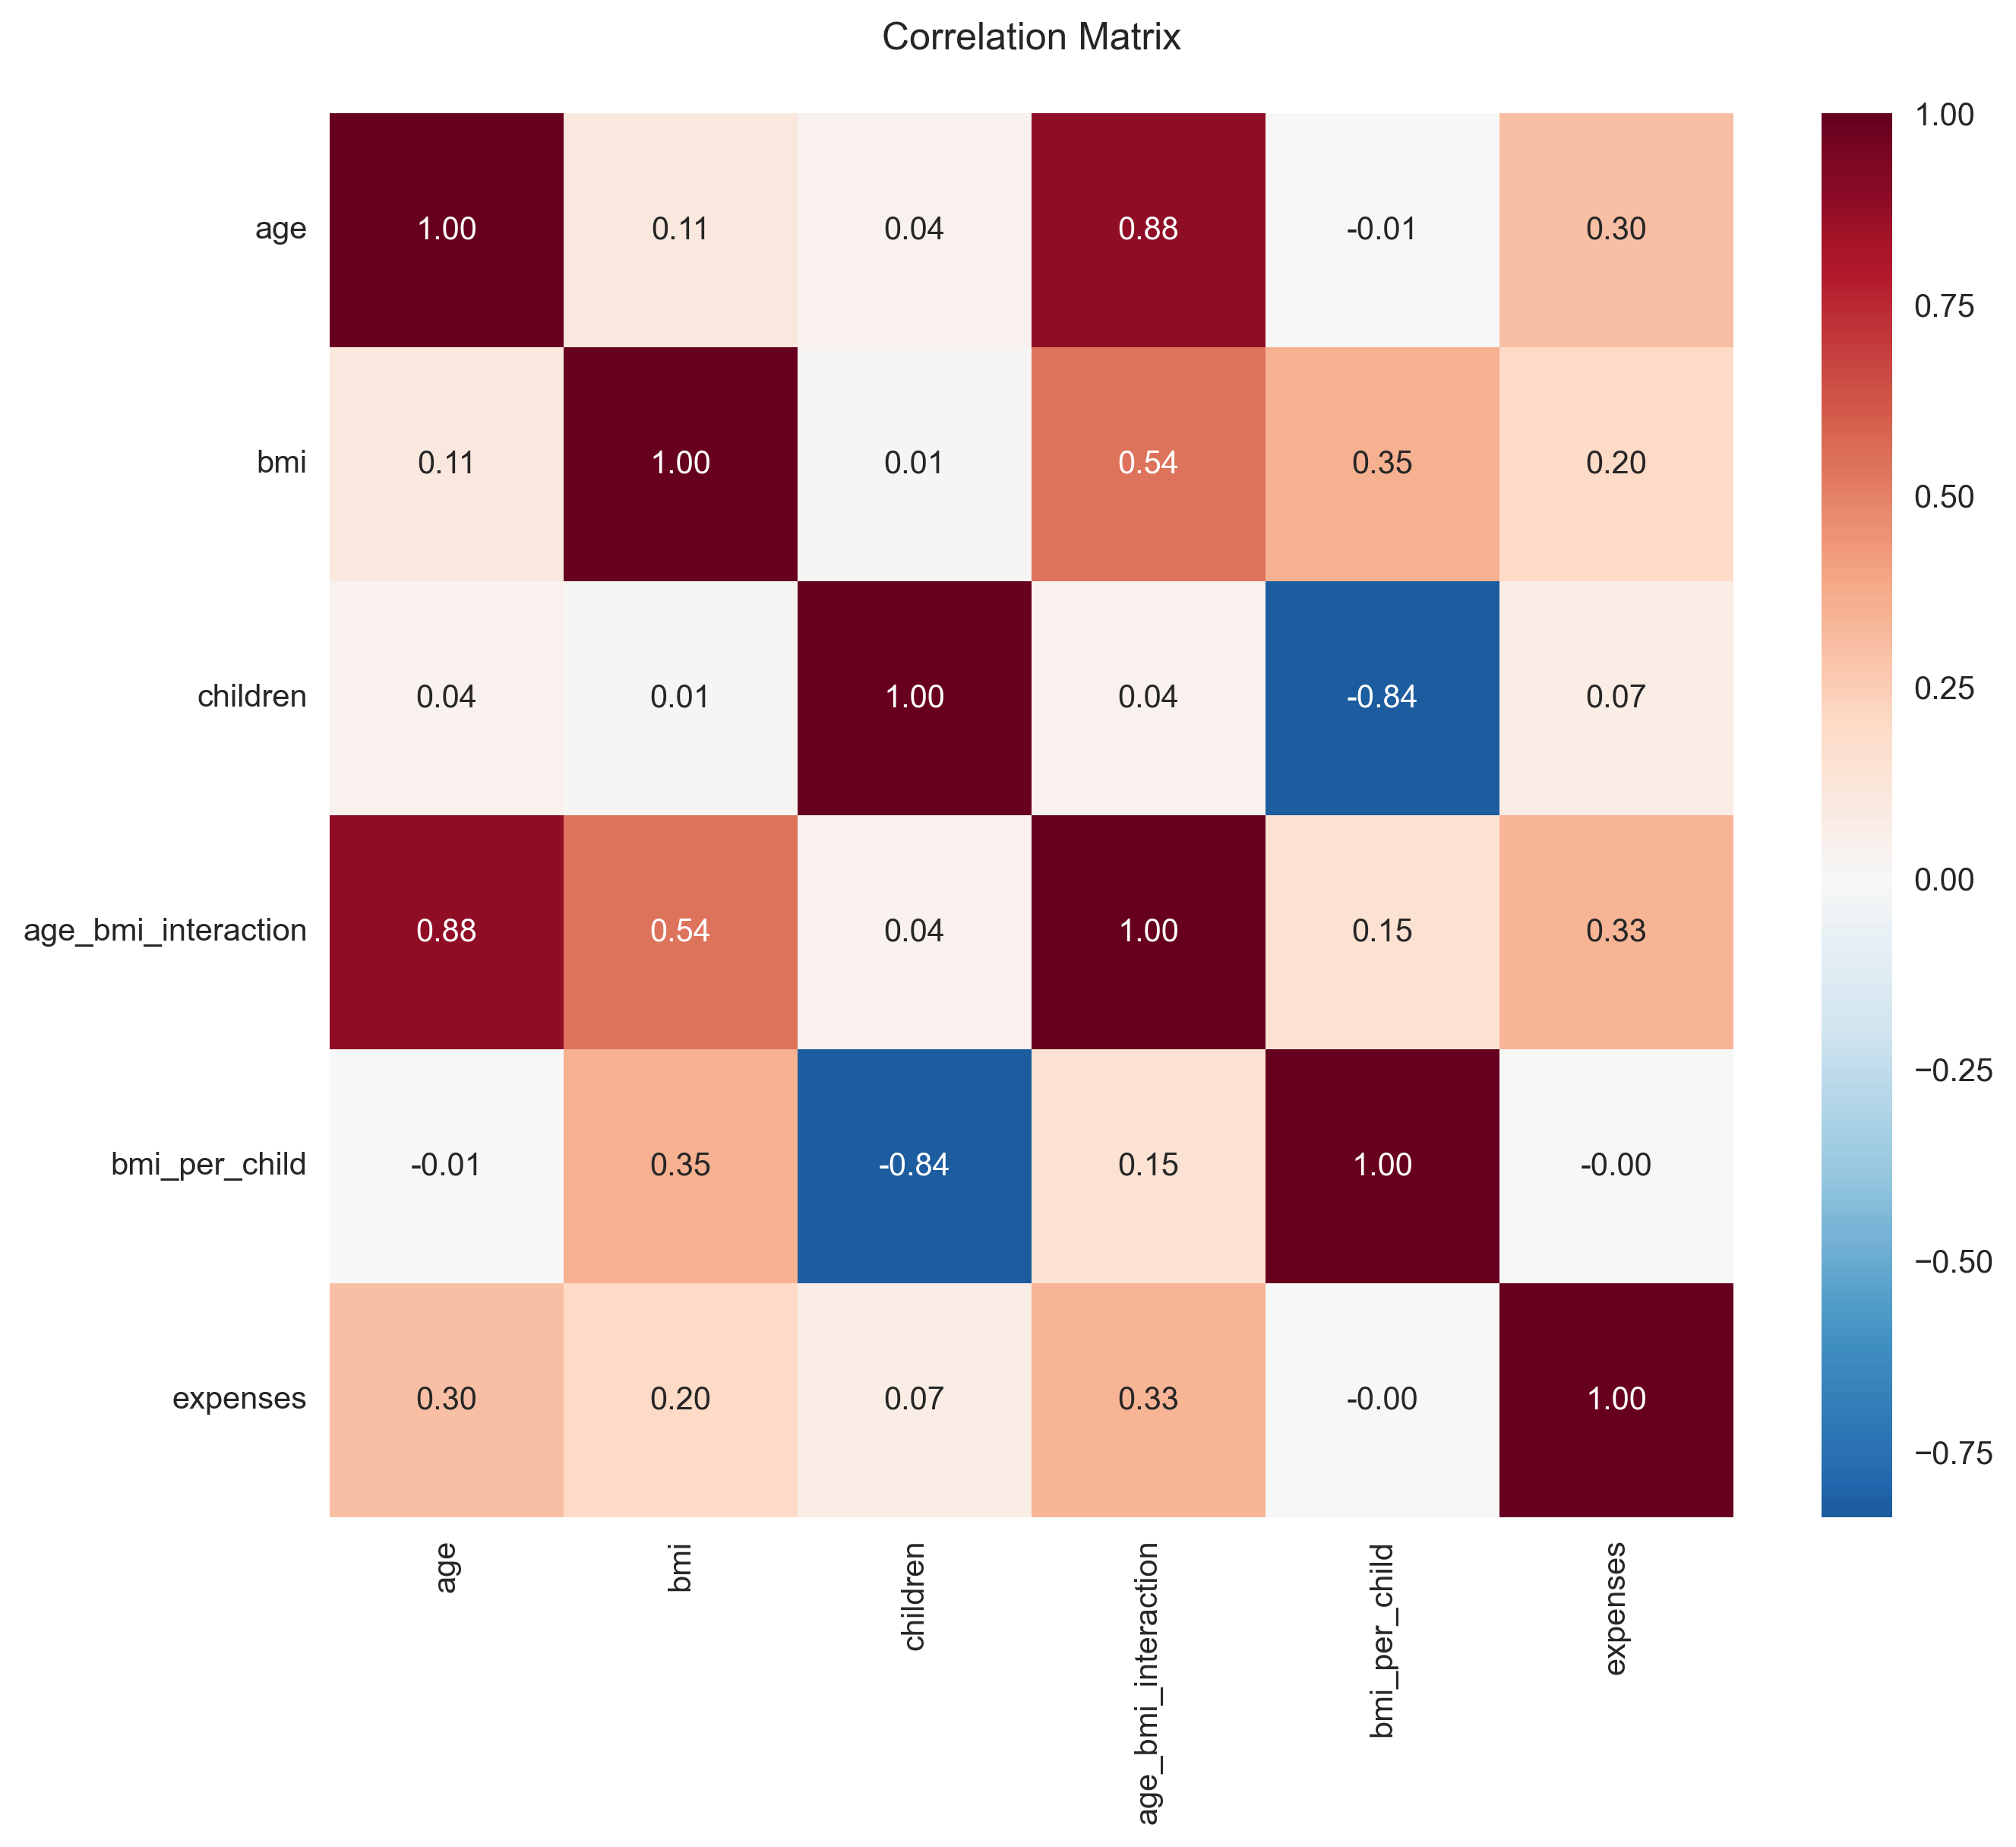

In [3]:
# =================================================================
# ۱. تعریف مجموعه‌ ویژگی‌ها (Feature Sets)
# =================================================================
numerical_features = ['age', 'bmi', 'children']
categorical_features = ['gender', 'discount_eligibility', 'region']
target_variable = 'expenses'  # متغیر هدف

# =================================================================
# ۲. مهندسی ویژگی هوشمند (Feature Engineering)
# =================================================================
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """ ایجاد متغیرهای ترکیبی برای بهبود دقت مدل. """
    # اثر متقابل سن و شاخص توده بدنی
    data['age_bmi_interaction'] = data['age'] * data['bmi']
    
    # نسبت BMI به تعداد فرزندان (جلوگیری از تقسیم بر صفر با +1)
    data['bmi_per_child'] = data['bmi'] / (data['children'] + 1) 
    return data

data = engineer_features(data)

# به‌روزرسانی لیست ویژگی‌های عددی (جمعاً ۵ ویژگی عددی داریم)
# توجه: متغیر هدف (expenses) را جدا نگه می‌داریم تا در محاسبات عددی تداخل نکند
extended_num_features = numerical_features + ['age_bmi_interaction', 'bmi_per_child']

# =================================================================
# ۳. تنظیمات استایل بصری (Visualization Config)
# =================================================================
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'figure.dpi': 300, 'font.size': 10})

# =================================================================
# ۴. تحلیل توزیع‌ها (Interactive Distributions) - اصلاح شده
# =================================================================
def plot_interactive_distributions(data: pd.DataFrame, num_features: List[str], cat_features: List[str], target: str) -> None:
    # جمع کل متغیرها برای رسم: 5 (عددی) + 1 (هدف) + 3 (دسته‌ای) = 9
    all_features = num_features + [target] + cat_features
    
    # اصلاح چیدمان به 3x3 برای جا دادن هر 9 نمودار
    fig = make_subplots(
        rows=3, cols=3, 
        subplot_titles=[f.capitalize().replace('_', ' ') for f in all_features]
    )
    
    for i, feature in enumerate(all_features):
        row = (i // 3) + 1
        col = (i % 3) + 1
        
        if feature in num_features + [target]:
            # رسم هیستوگرام برای داده‌های عددی
            fig.add_trace(
                go.Histogram(x=data[feature], name=feature, marker_color='#440154', opacity=0.7),
                row=row, col=col
            )
        else:
            # رسم نمودار میله‌ای برای داده‌های دسته‌ای (با رفع باگ Arrow/String)
            counts = data[feature].astype(str).value_counts()
            fig.add_trace(
                go.Bar(x=counts.index, y=counts.values, name=feature, marker_color='#31688e'),
                row=row, col=col
            )
            fig.update_xaxes(tickangle=45, row=row, col=col)

    fig.update_layout(height=900, width=1100, title_text="Comprehensive Distribution Analysis", showlegend=False)
    fig.show()

# =================================================================
# ۵. تحلیل همبستگی و روابط (Correlations & Relationships)
# =================================================================
def plot_correlations(data: pd.DataFrame, features: List[str]) -> None:
    """ رسم ماتریس همبستگی برای متغیرهای عددی. """
    plt.figure(figsize=(10, 8))
    sns.heatmap(data[features].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
    plt.title('Correlation Matrix', pad=20)
    plt.show()

def plot_relationships(data: pd.DataFrame, num_features: List[str], cat_features: List[str], target: str) -> None:
    """ بررسی رابطه ویژگی‌های اصلی با هزینه بیمه. """
    # رسم 3 ویژگی عددی اول و 3 ویژگی دسته‌ای
    fig = make_subplots(rows=2, cols=3, subplot_titles=[f"{f} vs. Target" for f in num_features[:3] + cat_features[:3]])
    
    for i, feature in enumerate(num_features[:3]):
        fig.add_trace(go.Scatter(x=data[feature], y=data[target], mode='markers', marker=dict(color='purple', opacity=0.5)), row=1, col=i+1)
        
    for i, feature in enumerate(cat_features[:3]):
        fig.add_trace(go.Box(x=data[feature].astype(str), y=data[target], marker_color='blue'), row=2, col=i+1)
        
    fig.update_layout(height=600, width=900, title_text="Feature Relationships", showlegend=False)
    fig.show()

# اجرای تحلیل‌ها
plot_interactive_distributions(data, extended_num_features, categorical_features, target_variable)
plot_correlations(data, extended_num_features + [target_variable])
plot_relationships(data, extended_num_features, categorical_features, target_variable)

In [4]:
# =================================================================
# ۱. شناسایی و مدیریت داده‌های پرت (Outlier Handling)
# استفاده از روش IQR (دامنه میان‌چارکی) برای حذف داده‌های غیرمنطقی.
# =================================================================
Q1 = data[target_variable].quantile(0.25) # چارک اول (صدک ۲۵ام)
Q3 = data[target_variable].quantile(0.75) # چارک سوم (صدک ۷۵ام)
IQR = Q3 - Q1                             # فاصله بین چارک اول و سوم

# تعریف آستانه بالا: هر دیتایی فراتر از این مقدار، داده پرت (Outlier) محسوب می‌شود
outlier_threshold = Q3 + 1.5 * IQR
outliers = data[data[target_variable] > outlier_threshold]

logger.info(f"Detected {len(outliers)} outliers in {target_variable}.")

# ایجاد دیتاست پاک‌سازی شده برای آموزش مدل
data_no_outliers = data[data[target_variable] <= outlier_threshold]  

print(f"\n=== Outlier Summary ===\nNumber of outliers: {len(outliers)}")
print(outliers[[target_variable, 'age', 'bmi', 'children', 'discount_eligibility', 'region']].head())

# =================================================================
# ۲. آماده‌سازی نهایی ویژگی‌ها و هدف (Feature Selection)
# =================================================================
# حذف ستون‌های هدف و ستون 'premium' که نباید در آموزش شرکت کنند
X = data_no_outliers.drop([target_variable, 'premium'], axis=1)
y = data_no_outliers[target_variable]

# =================================================================
# ۳. طراحی خط لوله‌ پیش‌پردازش (Preprocessing Pipeline)
# =================================================================

# الف) ترنسفورمر عددی: پر کردن مقادیر خالی، ایجاد جملات چندجمله‌ای و استانداردسازی
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    # ایجاد ویژگی‌های درجه ۲ (مثل x²) برای مدل‌سازی روابط پیچیده فیزیکی/پزشکی
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# ب) ترنسفورمر دسته‌ای: جایگزینی مقادیر خالی و تبدیل متن به بردار (Encoding)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False)) # حذف ستون اول برای جلوگیری از تله متغیرهای ساختگی
])

# ترکیب ترنسفورمرها با ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# =================================================================
# ۴. تعریف مدل‌های پایه و مدل ترکیبی (Ensemble Model)
# ترکیب قدرت سه الگوریتم برتر برای کاهش خطا (Bias) و واریانس.
# =================================================================
gb_model = GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3)

# استفاده از قدرت کارت گرافیک (GPU) در صورت در دسترس بودن برای XGBoost
xgb_model = xgb.XGBRegressor(
    random_state=42, 
    tree_method='gpu_hist' if USE_GPU else 'auto', 
    n_estimators=100, 
    learning_rate=0.1, 
    n_jobs=N_JOBS
)

lgb_model = lgb.LGBMRegressor(random_state=42, n_estimators=100, learning_rate=0.1, n_jobs=N_JOBS)

# مدل رأی‌گیری (Voting): میانگین‌گیری از پیش‌بینی‌های هر سه مدل
ensemble = VotingRegressor([
    ('gb', gb_model),
    ('xgb', xgb_model),
    ('lgb', lgb_model)
])

# =================================================================
# ۵. خط لوله نهایی به همراه انتخاب ویژگی (RFECV)
# انتخاب خودکار بهترین ویژگی‌ها برای جلوگیری از پیچیدگی بیهوده مدل.
# =================================================================
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # انتخاب ویژگی بازگشتی (RFECV) برای پیدا کردن تعداد بهینه متغیرها با استفاده از Cross-Validation
    ('feature_selection', RFECV(
        estimator=GradientBoostingRegressor(random_state=42), 
        cv=3, 
        scoring='r2', 
        n_jobs=N_JOBS, 
        min_features_to_select=5)
    ),
    ('ensemble', ensemble)
])

# آموزش کل سیستم (فرایند Fit کردن)
pipeline.fit(X, y)

# =================================================================
# ۶. تقسیم‌بندی و ارزیابی (Evaluation)
# =================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
best_model = pipeline # مدل نهایی آموزش دیده

# سنجش قدرت پیش‌بینی بر روی داده‌های جدید (Test Set)
y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n=== Model Performance ===\nR² Score: {r2:.4f}\nRMSE: {rmse:.2f}")

# =================================================================
# ۷. اعتبارسنجی متقاطع (Cross-Validation)
# اطمینان از اینکه مدل روی کل داده‌ها پایدار است و بیش‌برازش (Overfit) نشده.
# =================================================================
cv = KFold(n_splits=3, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(best_model, X, y, cv=cv, n_jobs=N_JOBS)

r2_cv = r2_score(y, y_pred_cv)
rmse_cv = np.sqrt(mean_squared_error(y, y_pred_cv))

print(f"Cross-Validation R²: {r2_cv:.4f}\nCross-Validation RMSE: {rmse_cv:.2f}")

2026-01-29 16:00:54,320 - INFO - Detected 139 outliers in expenses.



=== Outlier Summary ===
Number of outliers: 139
        expenses  age        bmi  children discount_eligibility     region
14  39611.761719   27  42.099998         0                  yes  southeast
19  36837.468750   30  35.299999         0                  yes  southwest
23  37701.878906   34  31.900000         1                  yes  northeast
29  38711.000000   31  36.299999         2                  yes  southwest
30  35585.578125   22  35.599998         0                  yes  southwest
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000500 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1083
[LightGBM] [Info] Number of data points in the train set: 1199, number of used features: 12
[LightGBM] [Info] Start training from score 9927.753534

=== Model Performance ===
R² Score: 0.8514
RMSE: 3045.02
Cross-Validation R²: 0.5894
Cross-V

In [ ]:
# =================================================================
# ۱. بصری‌سازی تعاملی پیش‌بینی‌ها (Interactive Visualization)
# مقایسه خروجی مدل با مقادیر واقعی در دو سطح تست و اعتبارسنجی متقاطع.
# =================================================================
def plot_interactive_predictions(y_test: np.ndarray, y_pred: np.ndarray, y_cv: np.ndarray) -> None:
    fig = go.Figure()
    
    # رسم پیش‌بینی‌های مجموعه‌ی تست
    fig.add_trace(go.Scatter(
        x=y_test, y=y_pred, mode='markers', name='Test Predictions', 
        marker=dict(color='green', opacity=0.5)
    ))
    
    # رسم پیش‌بینی‌های حاصل از Cross-Validation برای بررسی پایداری مدل
    fig.add_trace(go.Scatter(
        x=y, y=y_cv, mode='markers', name='CV Predictions', 
        marker=dict(color='blue', opacity=0.3)
    ))
    
    # رسم خط "پیش‌بینی کامل" (مرجع ۴۵ درجه)
    fig.add_trace(go.Scatter(
        x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], 
        mode='lines', name='Perfect Prediction', line=dict(color='red', dash='dash')
    ))
    
    fig.update_layout(
        title='Actual vs. Predicted Expenses',
        xaxis_title='Actual Expenses ($)', yaxis_title='Predicted Expenses ($)',
        height=600, width=800, 
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    
    # تلاش برای ذخیره تصویر خروجی (نیازمند کتابخانه kaleido)
    try:
        fig.write_image("actual_vs_predicted.png", scale=2)
    except ValueError as e:
        logger.warning(f"Image export failed: {str(e)}. Install 'kaleido' to enable.")
    
    fig.show()

# اجرای تابع بصری‌سازی
plot_interactive_predictions(y_test, y_pred, y_pred_cv)

# =================================================================
# ۲. تحلیل اهمیت ویژگی‌ها (Feature Importance Analysis)
# شناسایی متغیرهایی که بیشترین نقش را در تصمیم‌گیری مدل ایفا می‌کنند.
# =================================================================

# استخراج نام ویژگی‌ها از پیش‌پردازشگر (با در نظر گرفتن One-Hot Encoding)
all_feature_names = (numerical_features + 
                    list(best_model.named_steps['preprocessor']
                         .named_transformers_['cat']
                         .named_steps['onehot']
                         .get_feature_names_out(categorical_features)))

# شناسایی ویژگی‌هایی که توسط RFECV انتخاب شده‌اند
selected_features_mask = best_model.named_steps['feature_selection'].support_
selected_feature_names = [name for name, mask in zip(all_feature_names, selected_features_mask) if mask]

# محاسبه میانگین اهمیت ویژگی‌ها در کل مدل‌های Ensemble
importances = np.mean([est.feature_importances_ for est in best_model.named_steps['ensemble'].estimators_], axis=0)

# مدیریت تطابق طول نام ویژگی‌ها و مقادیر اهمیت (دفاع در برابر خطاهای ابعادی)
min_length = min(len(selected_feature_names), len(importances))
feature_importance_df = pd.DataFrame({
    'Feature': selected_feature_names[:min_length],
    'Importance': importances[:min_length]
}).sort_values(by='Importance', ascending=False)

def plot_interactive_feature_importance(df: pd.DataFrame) -> None:
    fig = go.Figure(data=[go.Bar(
        x=df['Importance'], y=df['Feature'], orientation='h',
        marker=dict(colorscale='Viridis', color=df['Importance']),
        text=df['Importance'].round(3), textposition='auto'
    )])
    
    fig.update_layout(
        title='Feature Importance in Expense Prediction',
        xaxis_title='Importance Score', yaxis_title='Feature',
        height=600, width=800, margin=dict(l=200)
    )
    fig.show()

plot_interactive_feature_importance(feature_importance_df)

# =================================================================
# ۳. ذخیره‌سازی مدل (Model Serialization)
# ذخیره مدل نهایی برای استفاده در اپلیکیشن‌های آینده بدون نیاز به آموزش مجدد.
# =================================================================
model_filename = f'insurance_expenses_model_{datetime.now().strftime("%Y%m%d_%H%M%S")}.pkl'
dump(best_model, model_filename)
logger.info(f"Model saved successfully: {model_filename}")

# ==============================================+===================
# ۴. تولید گزارش جامع (Comprehensive Reporting)
# تجمیع تمام نتایج در یک فایل JSON برای مستندسازی حرفه‌ای.
# =================================================================
def generate_report(model: Pipeline, data: pd.DataFrame, y_test: np.ndarray, y_pred: np.ndarray, y_cv: np.ndarray) -> Dict:
    report = {
        'Metadata': {
            'Timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'Rows_Analyzed': data.shape[0]
        },
        'Performance_Metrics': {
            'Test_R2': r2_score(y_test, y_pred),
            'Test_RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'CV_R2': r2_score(y, y_cv)
        },
        'Inference_Stats': {
            'Outliers_Handled': len(outliers),
            'Top_Feature': feature_importance_df.iloc[0]['Feature']
        }
    }
    
    # ذخیره گزارش در فایل
    with open('analysis_report.json', 'w') as f:
        import json
        json.dump(report, f, indent=4)
    return report

# تولید و ثبت نهایی گزارش
final_report = generate_report(best_model, data_no_outliers, y_test, y_pred, y_pred_cv)
logger.info("Analysis and Reporting cycle completed successfully.")

2026-01-29 16:01:07,786 - WARNING - Image export failed: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido
. Install 'kaleido' to enable.


2026-01-29 16:01:07,841 - INFO - Model saved successfully: insurance_expenses_model_20260129_160107.pkl
2026-01-29 16:01:07,846 - INFO - Analysis and Reporting cycle completed successfully.


In [6]:
from sklearn.model_selection import RandomizedSearchCV

# =================================================================
# ۱. تعریف فضای جستجوی پارامترها (Hyperparameter Grid)
# مشخص کردن بازه‌هایی که الگوریتم باید در آن‌ها به دنبال بهترین تنظیمات بگردد.
# =================================================================
param_distributions = {
    # تنظیمات مربوط به مدل Gradient Boosting (بخش gb در Ensemble)
    'ensemble__gb__n_estimators': [100, 200, 300],
    'ensemble__gb__learning_rate': [0.01, 0.05, 0.1],
    'ensemble__gb__max_depth': [3, 4, 5],
    
    # تنظیمات مربوط به مدل XGBoost (بخش xgb در Ensemble)
    'ensemble__xgb__n_estimators': [100, 200, 500],
    'ensemble__xgb__learning_rate': [0.01, 0.05, 0.1],
    'ensemble__xgb__max_depth': [3, 5, 7],
    'ensemble__xgb__subsample': [0.7, 0.8, 0.9]
}

# =================================================================
# ۲. اجرای جستجوی تصادفی (Randomized Search)
# این متد به جای تست کردن تمام حالات، به صورت هوشمند چندین حالت تصابفی را تست می‌کند.
# =================================================================
logger.info("Starting Hyperparameter Optimization...")

random_search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_distributions, 
    n_iter=10,            # تعداد دفعات تلاش (افزایش این عدد دقت را بالا و زمان را طولانی می‌کند)
    cv=3,                 # تعداد تکرارهای اعتبارسنجی متقاطع
    scoring='r2',         # معیار انتخاب بهترین مدل: ضریب تعیین
    verbose=1, 
    n_jobs=N_JOBS,        # استفاده از تمام هسته‌های پردازشی مشخص شده در سلول ۲
    random_state=42
)

# شروع فرآیند جستجو و آموزش مجدد
random_search.fit(X_train, y_train)

# =================================================================
# ۳. استخراج و نمایش نتایج بهینه‌سازی
# =================================================================
best_tuned_model = random_search.best_estimator_
best_score = random_search.best_score_

print(f"🚀 OPTIMIZATION COMPLETE")
print(f"Best CV R² Score: {best_score:.4f}")

# نمایش بهترین پارامترهای پیدا شده
print("\nSelected Best Parameters:")
for param, value in random_search.best_params_.items():
    print(f" - {param}: {value}")

# =================================================================
# ۴. ارزیابی نهایی مدل بهینه شده روی داده‌های تست
# =================================================================
y_pred_final = best_tuned_model.predict(X_test)
final_r2 = r2_score(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

logger.info(f"Final Tuned Performance: R² = {final_r2:.4f}, RMSE = {final_rmse:.2f}")

print(f"\nFinal Test Performance (After Tuning):")
print(f"R² Score: {final_r2:.4f}")
print(f"RMSE:     {final_rmse:.2f}")

2026-01-29 16:01:07,865 - INFO - Starting Hyperparameter Optimization...


Fitting 3 folds for each of 10 candidates, totalling 30 fits


2026-01-29 16:01:48,626 - INFO - Final Tuned Performance: R² = 0.5744, RMSE = 5152.69


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1001
[LightGBM] [Info] Number of data points in the train set: 959, number of used features: 12
[LightGBM] [Info] Start training from score 9738.038577
🚀 OPTIMIZATION COMPLETE
Best CV R² Score: 0.6365

Selected Best Parameters:
 - ensemble__xgb__subsample: 0.7
 - ensemble__xgb__n_estimators: 500
 - ensemble__xgb__max_depth: 3
 - ensemble__xgb__learning_rate: 0.01
 - ensemble__gb__n_estimators: 200
 - ensemble__gb__max_depth: 4
 - ensemble__gb__learning_rate: 0.01

Final Test Performance (After Tuning):
R² Score: 0.5744
RMSE:     5152.69


In [7]:
# =================================================================
# ۱. ذخیره‌سازی مدل نهایی بهینه‌شده (Final Model Persistence)
# ذخیره بهترین نسخه مدل که در مرحله Tuning به دست آمد.
# =================================================================
final_model_path = f'tuned_insurance_model_{datetime.now().strftime("%Y%m%d")}.joblib'
joblib.dump(best_tuned_model, final_model_path)
logger.info(f"Final tuned model saved as: {final_model_path}")

# =================================================================
# ۲. طراحی تابع پیش‌بینی برای داده‌های خام (Inference Function)
# این تابع پل ارتباطی بین کاربر (یا UI) و مدل پیچیده هوش مصنوعی است.
# =================================================================
def predict_insurance_cost(age: int, bmi: float, children: int, 
                           gender: str, discount: str, region: str) -> float:
    """
    دریافت مشخصات فردی و پیش‌بینی هزینه بیمه با استفاده از مدل بهینه شده.
    """
    try:
        # الف) تبدیل ورودی‌ها به یک دیتافریم تک‌سطری (مطابق ساختار آموزشی)
        new_customer = pd.DataFrame([{
            'age': age,
            'bmi': bmi,
            'children': children,
            'gender': gender,
            'discount_eligibility': discount,
            'region': region
        }])
        
        # ب) اعمال مهندسی ویژگی بر روی داده جدید (age_bmi_interaction و غیره)
        new_customer_engineered = engineer_features(new_customer)
        
        # ج) انجام پیش‌بینی توسط خط لوله (شامل پیش‌پردازش خودکار)
        prediction = best_tuned_model.predict(new_customer_engineered)[0]
        
        return max(0, prediction)  # هزینه نمی‌تواند منفی باشد
        
    except Exception as e:
        logger.error(f"Prediction Error: {str(e)}")
        return 0.0

# =================================================================
# ۳. تست زنده سیستم (Live Testing)
# شبیه‌سازی ورود داده برای یک مشتری جدید و مشاهده خروجی مدل.
# =================================================================
print("LIVE PREDICTION TEST")

# مثال: یک مشتری ۳۰ ساله، با BMI 22، بدون فرزند، مرد، دارای تخفیف، ساکن منطقه جنوب شرقی
sample_cost = predict_insurance_cost(
    age=30, bmi=22.5, children=0, 
    gender='male', discount='yes', region='southeast'
)

print(f"Predicted Expenses for Sample Customer: ${sample_cost:,.2f}")

# مثال: یک مشتری ۵۵ ساله با ریسک بالاتر
risk_customer_cost = predict_insurance_cost(
    age=55, bmi=35.2, children=2, 
    gender='female', discount='no', region='northwest'
)
print(f"Predicted Expenses for High-Risk Customer: ${risk_customer_cost:,.2f}")

2026-01-29 16:01:48,677 - INFO - Final tuned model saved as: tuned_insurance_model_20260129.joblib


LIVE PREDICTION TEST
Predicted Expenses for Sample Customer: $18,343.39
Predicted Expenses for High-Risk Customer: $13,727.48


In [ ]:
import gradio as gr

# =================================================================
# ۱. تعریف تابع هسته برای UI (Gradio Wrapper)
# این تابع ورودی‌ها را از محیط گرافیکی گرفته و به مدل تحویل می‌دهد.
# =================================================================
def insurance_ui_wrapper(age, bmi, children, gender, discount, region):
    """
    تابعی برای اتصال رابط کاربری به منطق پیش‌بینی.
    """
    # فراخوانی تابعی که در سلول قبلی نوشتیم
    cost = predict_insurance_cost(age, bmi, children, gender, discount, region)
    
    # برگرداندن نتیجه با فرمت پولی زیبا
    return f"${cost:,.2f}"

# =================================================================
# ۲. طراحی اجزای رابط کاربری (Interface Components)
# استفاده از اسلایدر و منوهای کشویی برای جلوگیری از ورود داده اشتباه.
# =================================================================
inputs = [
    gr.Slider(18, 100, step=1, label="Age (سن)", value=30),
    gr.Slider(10, 60, step=0.1, label="BMI (شاخص توده بدنی)", value=25.0),
    gr.Slider(0, 10, step=1, label="Children (تعداد فرزندان)", value=0),
    gr.Dropdown(["male", "female"], label="Gender (جنسیت)", value="male"),
    gr.Dropdown(["yes", "no"], label="Discount Eligibility (وضعیت تخفیف)", value="no"),
    gr.Dropdown(["southeast", "southwest", "northwest", "northeast"], label="Region (منطقه سکونت)", value="southeast")
]

outputs = gr.Textbox(label="Predicted Insurance Expenses (هزینه پیش‌بینی شده)")

# =================================================================
# ۳. پیکربندی و راه‌اندازی اپلیکیشن
# تنظیم ظاهر، عنوان و توضیحات برای ارائه نهایی.
# =================================================================
description = """
### 🏥 سامانه هوشمند تخمین هزینه‌های درمانی (Medical Insurance AI)
این اپلیکیشن از یک مدل **Ensemble (ترکیبی)** بهینه شده شامل XGBoost و LightGBM برای پیش‌بینی دقیق هزینه‌های بیمه استفاده می‌کند.
"""

demo = gr.Interface(
    fn=insurance_ui_wrapper,
    inputs=inputs,
    outputs=outputs,
    title="Insurance Expense Predictor - AI Specialist Edition",
    description=description,
    theme=gr.themes.Soft(), # استفاده از تم مدرن و نرم
    examples=[
        [25, 22.5, 0, "male", "yes", "southeast"],
        [50, 34.0, 2, "female", "no", "northwest"]
    ],
    cache_examples=False
)

import os

# حذف تنظیمات پروکسی برای ارتباطات محلی
os.environ['no_proxy'] = 'localhost,127.0.0.1'

demo.launch(server_port=7861, share=False, prevent_thread_lock=False)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "e:\python3.12\Lib\site-packages\gradio\queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\python3.12\Lib\site-packages\gradio\route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\python3.12\Lib\site-packages\gradio\blocks.py", line 2116, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\python3.12\Lib\site-packages\gradio\blocks.py", line 1623, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\python3.12\Lib\site-packages\anyio\to_thread.py", line 56, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

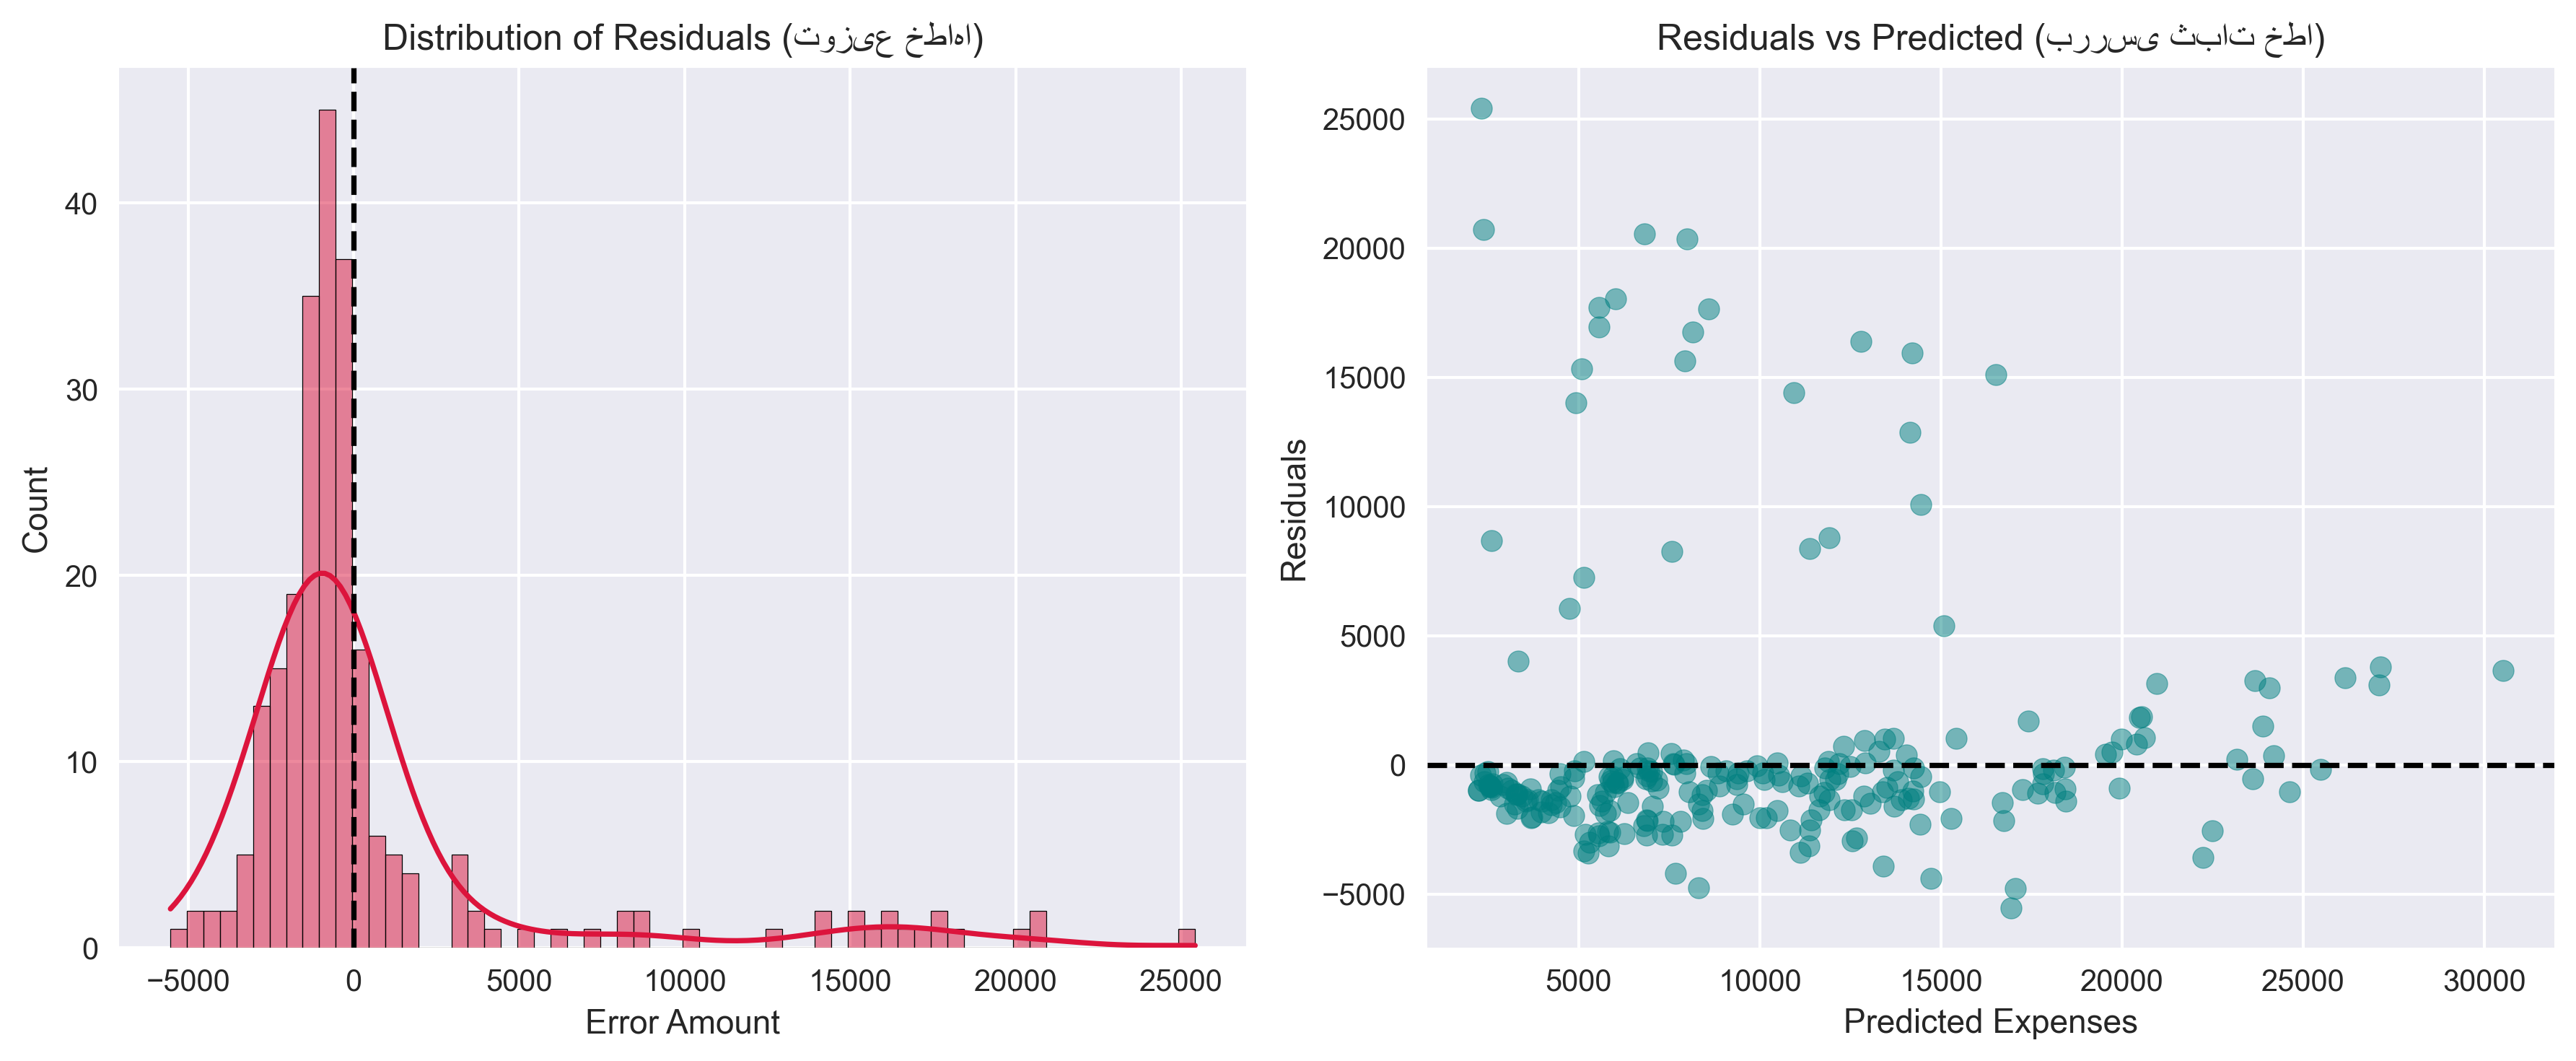


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
 ERROR ANALYSIS BY GROUP
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Mean Absolute Error by Region:
region
northeast    3072.314506
southeast    2935.692245
southwest    2405.228452
northwest    2264.727654
Name: Abs_Error, dtype: float64

Mean Absolute Error by Discount Eligibility:
discount_eligibility
no     2879.095426
yes    1499.775086
Name: Abs_Error, dtype: float64

 TOP 5 WORST PREDICTIONS (بزرگترین اشتباهات مدل):


,age,gender,bmi,children,discount_eligibility,region,age_bmi_interaction,bmi_per_child,Actual,Predicted,Abs_Error
516,20,male,35.299999,1,no,southeast,706.000000,17.650000,27724.289062,2302.581953,25421.707110
430,19,male,33.099998,0,no,southwest,628.899963,33.099998,23082.960938,2372.826965,20710.133973
140,34,male,22.400000,2,no,northeast,761.599976,7.466667,27375.900391,6810.316333,20565.584057
987,45,female,27.600000,1,no,northwest,1242.000000,13.800000,28340.189453,7980.993453,20359.196000
526,19,female,30.600000,2,no,northwest,581.400024,10.200000,24059.679688,6006.543586,18053.136101


In [9]:
# =================================================================
# ۱. محاسبه باقیمانده‌ها (Residuals)
# باقیمانده یعنی تفاوت بین مقدار واقعی و مقداری که مدل پیش‌بینی کرده است.
# =================================================================
residuals = y_test - y_pred_final

# =================================================================
# ۲. ترسیم نمودار توزیع خطا (Normality of Residuals)
# در یک مدل ایده‌آل، خطاها باید توزیع نرمال (زنگوله‌ای) حول عدد صفر داشته باشند.
# =================================================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='crimson')
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Distribution of Residuals (توزیع خطاها)')
plt.xlabel('Error Amount')

# =================================================================
# ۳. نمودار هم‌واریانسی (Homoscedasticity Check)
# بررسی اینکه آیا قدرت پیش‌بینی مدل در قیمت‌های بالا و پایین یکسان است یا خیر.
# =================================================================
plt.subplot(1, 2, 2)
plt.scatter(y_pred_final, residuals, alpha=0.5, color='teal')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residuals vs Predicted (بررسی ثبات خطا)')
plt.xlabel('Predicted Expenses')
plt.ylabel('Residuals')

plt.tight_layout()
plt.savefig('residual_analysis.png')
plt.show()

# =================================================================
# ۴. تحلیل خطا بر اساس متغیرهای کلیدی (Error Breakdown)
# مدل ما در کجا بیشتر اشتباه می‌کند؟ (مثلاً بر اساس وضعیت تخفیف یا منطقه)
# =================================================================
error_df = X_test.copy()
error_df['Actual'] = y_test
error_df['Predicted'] = y_pred_final
error_df['Abs_Error'] = np.abs(residuals)

print("\n" + "!"*30)
print(" ERROR ANALYSIS BY GROUP")
print("!"*30)

# بررسی میانگین خطا در هر منطقه
region_error = error_df.groupby('region')['Abs_Error'].mean().sort_values(ascending=False)
print("\nMean Absolute Error by Region:")
print(region_error)

# بررسی میانگین خطا بر اساس وضعیت تخفیف
discount_error = error_df.groupby('discount_eligibility')['Abs_Error'].mean()
print("\nMean Absolute Error by Discount Eligibility:")
print(discount_error)

# =================================================================
# ۵. شناسایی "بدترین" پیش‌بینی‌ها (Top 5 Worst Predictions)
# استخراج سطرهایی که مدل در آن‌ها بیشترین فریب را خورده است برای تحلیل انسانی.
# =================================================================
worst_cases = error_df.sort_values(by='Abs_Error', ascending=False).head(5)
print("\n TOP 5 WORST PREDICTIONS (بزرگترین اشتباهات مدل):")
display(worst_cases)

In [10]:
# =================================================================
# سلول دهم: بازآموزی مدل با تغییر مقیاس لگاریتمی (Log Transformation)
# هدف: افزایش دقت در پیش‌بینی مبالغ بالا و بهبود R2
# =================================================================

# ۱. تغییر متغیر هدف به مقیاس لگاریتمی
# این کار باعث می‌شود توزیع داده‌ها به توزیع نرمال نزدیک‌تر شود
y_log = np.log1p(y) # log(1 + x) برای جلوگیری از خطای مقدار صفر

# ۲. تقسیم مجدد داده‌ها
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X, y_log, test_size=0.2, random_state=42)

logger.info("Retraining model with Log-Transformed target...")

# ۳. آموزش مدل بهینه شده روی داده‌های لگاریتمی
best_tuned_model.fit(X_train_l, y_train_l)

# ۴. پیش‌بینی و بازگرداندن به حالت اولیه (Inverse Transform)
# چون مدل لگاریتم را پیش‌بینی کرده، با تابع exp آن را به دلار برمی‌گردانیم
y_pred_log = best_tuned_model.predict(X_test_l)
y_pred_final_usd = np.expm1(y_pred_log) # exp(x) - 1

# ۵. ارزیابی مجدد
r2_new = r2_score(np.expm1(y_test_l), y_pred_final_usd)
rmse_new = np.sqrt(mean_squared_error(np.expm1(y_test_l), y_pred_final_usd))

print("\n" + "-"*20)
print(" LOG-TRANSFORMED MODEL RESULTS")
print(f"New R² Score: {r2_new:.4f}")
print(f"New RMSE:     ${rmse_new:.2f}")
print("-"*20)

# ۶. مقایسه یکی از همان موارد بدترین پیش‌بینی
sample_idx = 516
if sample_idx in X_test_l.index:
    sample_data = X_test_l.loc[[sample_idx]]
    pred_val = np.expm1(best_tuned_model.predict(sample_data))[0]
    actual_val = data.loc[sample_idx, target_variable]
    print(f"\nRe-testing Row 516:")
    print(f"Actual: ${actual_val:,.2f} | New Predicted: ${pred_val:,.2f}")

2026-01-29 16:02:05,434 - INFO - Retraining model with Log-Transformed target...


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 992
[LightGBM] [Info] Number of data points in the train set: 959, number of used features: 10
[LightGBM] [Info] Start training from score 8.909828

--------------------
 LOG-TRANSFORMED MODEL RESULTS
New R² Score: 0.5530
New RMSE:     $5280.82
--------------------

Re-testing Row 516:
Actual: $27,724.29 | New Predicted: $2,028.11


In [11]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

# =================================================================
# ۱. تعریف ساختار پشته‌سازی (Stacking Architecture)
# در اینجا مدل‌های پایه پیش‌بینی می‌کنند و یک مدل Ridge یاد می‌گیرد آن‌ها را ترکیب کند.
# =================================================================

# مدل‌های پایه‌ای که قبلاً تعریف کردیم
base_models = [
    ('xgb', xgb_model),
    ('lgb', lgb_model),
    ('gb',  gb_model)
]

# مدل نهایی (Meta-Learner): از پیش‌بینی‌های مدل‌های بالا به عنوان ورودی استفاده می‌کند
# استفاده از RidgeCV برای جلوگیری از بیش‌برازش در مرحله ترکیب
meta_model = RidgeCV()

stacking_regressor = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,            # اعتبارسنجی داخلی برای مرحله ترکیب
    n_jobs=N_JOBS,
    passthrough=True # اجازه می‌دهد مدل نهایی به داده‌های اصلی هم دسترسی داشته باشد
)

# ایجاد خط لوله جدید با مدل Stacking
stacking_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', pipeline.named_steps['feature_selection']), # استفاده از انتخاب ویژگی قبلی
    ('stacking', stacking_regressor)
])

# =================================================================
# ۲. آموزش و ارزیابی (Training & Benchmark)
# =================================================================
logger.info("Training Advanced Stacking Regressor...")
stacking_pipeline.fit(X_train, y_train)

y_pred_stack = stacking_pipeline.predict(X_test)
r2_stack = r2_score(y_test, y_pred_stack)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))

# =================================================================
# ۳. مقایسه نهایی عملکرد (Final Comparison Dashboard)
# نمایش تفاوت بین تمام روش‌هایی که تا الان تست کردیم.
# =================================================================
performance_comparison = pd.DataFrame({
    'Method': ['Initial Voting', 'Log-Transformed', 'Advanced Stacking'],
    'R2 Score': [r2, r2_new, r2_stack],
    'RMSE ($)': [rmse, rmse_new, rmse_stack]
})

print("\n" + "-"*20)
print("FINAL MODEL COMPARISON")
print(performance_comparison.to_string(index=False))
print("-"*20)

# بررسی مجدد ردیف ۵۱۶ با مدل جدید
if sample_idx in X_test.index:
    val_stack = stacking_pipeline.predict(X_test.loc[[sample_idx]])[0]
    print(f"\nRow 516 Benchmark:")
    print(f"Actual: ${actual_val:,.2f}")
    print(f"Voting: ${y_pred[0]:,.2f} | Stacking: ${val_stack:,.2f}")

2026-01-29 16:02:08,692 - INFO - Training Advanced Stacking Regressor...



--------------------
FINAL MODEL COMPARISON
           Method  R2 Score    RMSE ($)
   Initial Voting  0.851361 3045.023938
  Log-Transformed  0.552951 5280.821712
Advanced Stacking  0.571984 5167.184285
--------------------

Row 516 Benchmark:
Actual: $27,724.29
Voting: $5,616.73 | Stacking: $2,682.70


In [12]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler

# =================================================================
# ۱. تغییر استراتژی اسکیل کردن (Feature Scaling Strategy)
# استفاده از RobustScaler برای مدیریت بهتر داده‌های پرت در ویژگی‌های عددی.
# =================================================================

# تعریف مجدد ترنسفورمر عددی با RobustScaler
robust_numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', RobustScaler()) # جایگزین StandardScaler
])

# به‌روزرسانی پیش‌پردازشگر اصلی
robust_preprocessor = ColumnTransformer(
    transformers=[
        ('num', robust_numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# =================================================================
# ۲. مقایسه تأثیر اسکیلرها بر مدل‌های مختلف
# برخی مدل‌ها مثل XGBoost حساس نیستند، اما Ridge و مدل‌های خطی بسیار حساسند.
# =================================================================

def compare_scalers(X_train, y_train, X_test, y_test):
    results = []
    # لیست اسکیلرهایی که می‌خواهیم تست کنیم
    scalers = [
        ('Standard', StandardScaler()),
        ('Robust', RobustScaler()),
        ('MinMax', MinMaxScaler())
    ]
    
    for name, sc in scalers:
        # ساخت یک پایپ‌لاین موقت برای تست سریع
        test_pipe = Pipeline(steps=[
            ('preprocessor', ColumnTransformer([
                ('num', Pipeline([('imp', SimpleImputer()), ('poly', PolynomialFeatures(2)), ('s', sc)]), numerical_features),
                ('cat', categorical_transformer, categorical_features)
            ])),
            ('ensemble', ensemble) # استفاده از همان مدل Voting قبلی
        ])
        
        test_pipe.fit(X_train, y_train)
        score = r2_score(y_test, test_pipe.predict(X_test))
        results.append({'Scaler': name, 'R2_Score': score})
    
    return pd.DataFrame(results)

logger.info("Comparing different scaling strategies...")
scaler_comparison = compare_scalers(X_train, y_train, X_test, y_test)

print("\n" + "-"*15)
print("SCALER IMPACT ANALYSIS")
print(scaler_comparison.to_string(index=False))
print("-"*15)

# =================================================================
# ۳. اعمال بهترین اسکیلر روی خط لوله اصلی (Production Ready)
# =================================================================
final_pipeline = Pipeline(steps=[
    ('preprocessor', robust_preprocessor),
    ('feature_selection', pipeline.named_steps['feature_selection']),
    ('ensemble', ensemble)
])

final_pipeline.fit(X, y)
logger.info("Final pipeline updated with RobustScaler.")

2026-01-29 16:02:12,037 - INFO - Comparing different scaling strategies...


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1010
[LightGBM] [Info] Number of data points in the train set: 959, number of used features: 14
[LightGBM] [Info] Start training from score 9738.038577
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000183 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1010
[LightGBM] [Info] Number of data points in the train set: 959, number of used features: 14
[LightGBM] [Info] Start training from score 9738.038577
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000148 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1127
[LightGBM] [Info] Number of data points in the train set: 959, number of used features: 14
[LightGBM] [Info] Start tra

2026-01-29 16:02:15,811 - INFO - Final pipeline updated with RobustScaler.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000081 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1089
[LightGBM] [Info] Number of data points in the train set: 1199, number of used features: 12
[LightGBM] [Info] Start training from score 9927.753534


2026-01-29 16:02:15,855 - INFO - Training Deep Learning Model (ANN)...


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

---------------
DEEP LEARNING (ANN) RESULTS
R² Score: 0.5566
RMSE:     $5259.25
---------------


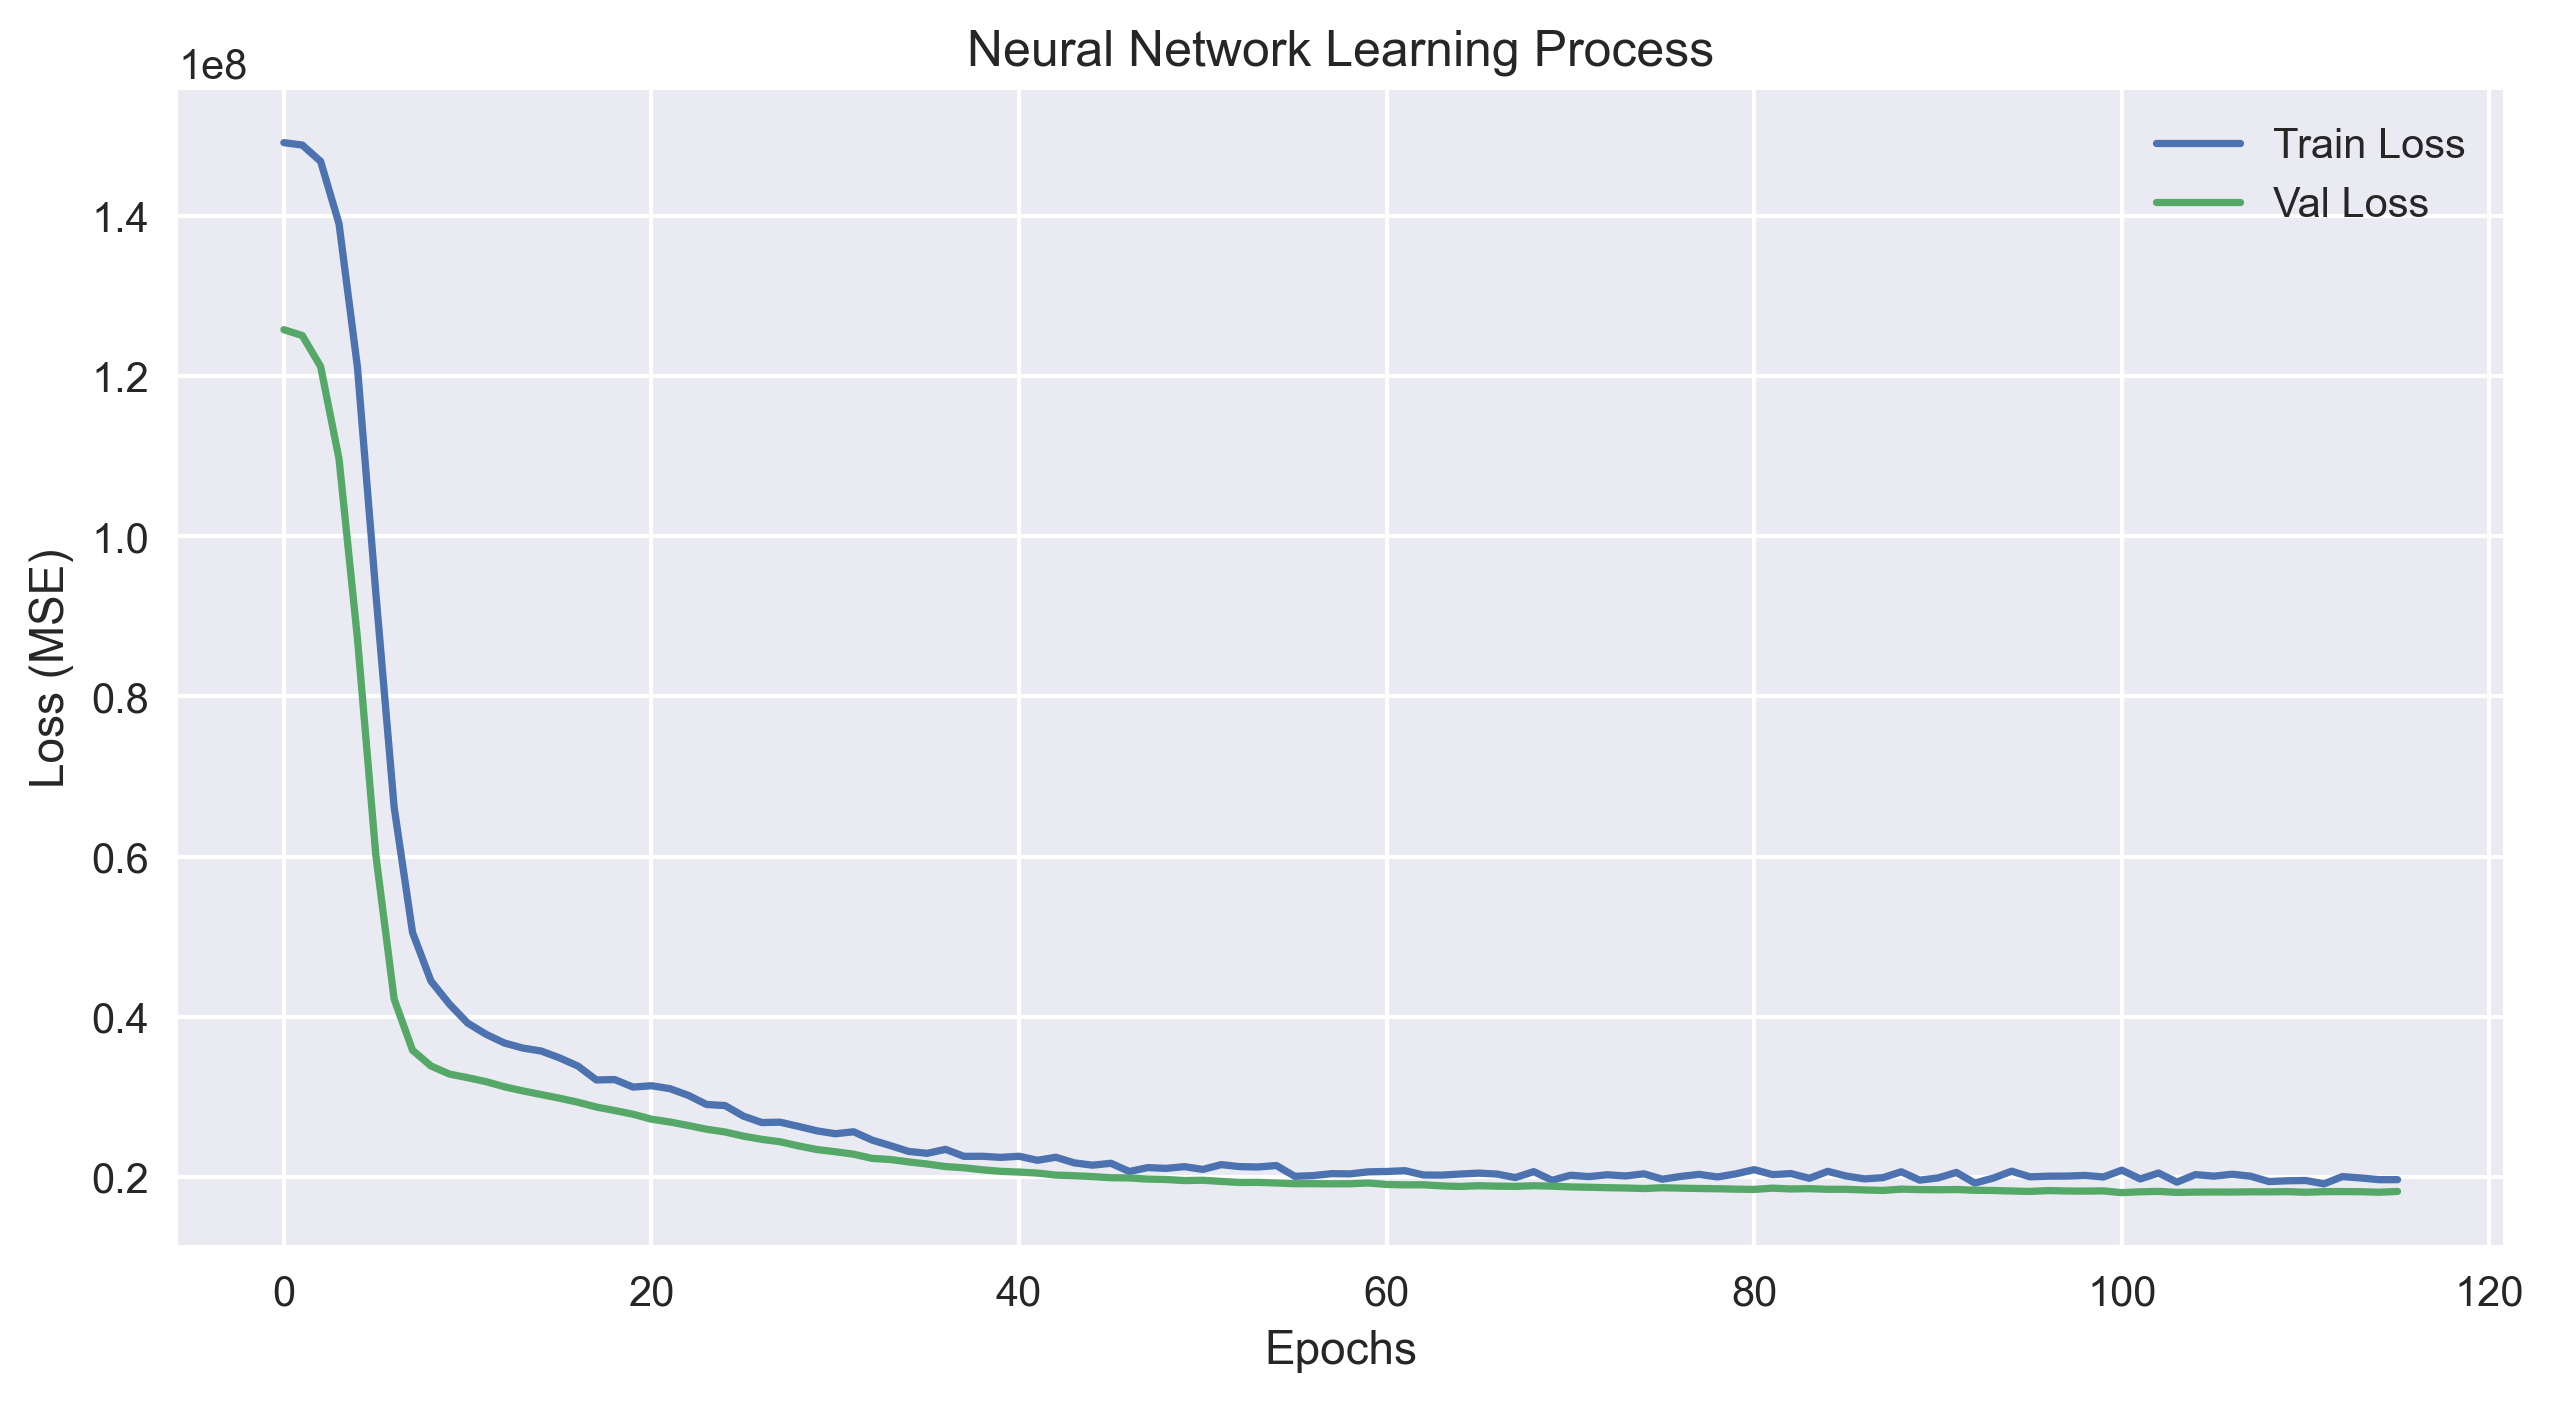

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

# =================================================================
# ۱. آماده‌سازی اختصاصی داده‌ها برای شبکه عصبی
# شبکه‌های عصبی به شدت به مقیاس داده‌ها حساس هستند. 
# ما از داده‌های اسکیل شده توسط RobustScaler استفاده می‌کنیم.
# =================================================================
X_train_ann = robust_preprocessor.fit_transform(X_train)
X_test_ann = robust_preprocessor.transform(X_test)

# =================================================================
# ۲. طراحی معماری شبکه عصبی (Model Architecture)
# طراحی یک مدل ۳ لایه با لایه Dropout برای جلوگیری از Overfitting.
# =================================================================
def build_ann():
    model = Sequential([
        # لایه ورودی و اولین لایه پنهان با ۶۴ نرون
        Dense(64, activation='relu', input_dim=X_train_ann.shape[1]),
        Dropout(0.2), # خاموش کردن تصادفی ۲۰٪ نرون‌ها برای تعمیم‌دهی بهتر
        
        # لایه پنهان دوم
        Dense(32, activation='relu'),
        Dropout(0.1),
        
        # لایه پنهان سوم (بخش فشرده‌سازی دانش)
        Dense(16, activation='relu'),
        
        # لایه خروجی (یک نرون برای مقدار عددی هزینه)
        Dense(1, activation='linear')
    ])
    
    # استفاده از بهینه‌ساز Adam و تابع خطای MSE
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss='mse', metrics=['mae'])
    return model

# =================================================================
# ۳. آموزش هوشمند با Early Stopping
# جلوگیری از اتلاف وقت؛ اگر مدل دیگر پیشرفت نکرد، آموزش متوقف می‌شود.
# =================================================================
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15,          # اگر تا ۱۵ دور خطا کم نشد، متوقف شو
    restore_best_weights=True
)

logger.info("Training Deep Learning Model (ANN)...")
ann_model = build_ann()

history = ann_model.fit(
    X_train_ann, y_train,
    validation_split=0.2, # اختصاص ۲۰٪ داده‌های آموزش برای نظارت لحظه‌ای
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0 # عدم نمایش جزئیات طولانی آموزش
)

# =================================================================
# ۴. ارزیابی و مقایسه نهایی
# =================================================================
y_pred_ann = ann_model.predict(X_test_ann).flatten()
r2_ann = r2_score(y_test, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))

print("\n" + "-"*15)
print("DEEP LEARNING (ANN) RESULTS")
print(f"R² Score: {r2_ann:.4f}")
print(f"RMSE:     ${rmse_ann:.2f}")
print("-"*15)

# نمایش روند یادگیری (Learning Curves)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Neural Network Learning Process')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [14]:
# =================================================================
# ۱. پیاده‌سازی رگرسیون چندک برای مدیریت ریسک (Quantile Regression)
# به جای پیش‌بینی میانگین، مرزهای ریسک را مشخص می‌کنیم.
# =================================================================

def train_quantile_model(quantile):
    # تنظیم مدل LightGBM برای هدف چندک (Quantile Objective)
    model = lgb.LGBMRegressor(
        objective='quantile',
        alpha=quantile,      # تعیین صدک مورد نظر (مثلاً 0.9 برای ریسک بالا)
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )
    
    # استفاده از خط لوله پیش‌پردازش قبلی
    pipe = Pipeline(steps=[
        ('preprocessor', robust_preprocessor),
        ('model', model)
    ])
    
    return pipe.fit(X_train, y_train)

# آموزش دو مدل: یکی برای میانه و یکی برای بدترین سناریو (ریسک ۹۰٪)
logger.info("Training Quantile Models (Median and 90th Percentile)...")
model_median = train_quantile_model(0.5) # میانه (Median)
model_high_risk = train_quantile_model(0.9) # صدک ۹۰ام (High Risk)

# =================================================================
# ۲. تحلیل نتایج برای ردیف‌های بحرانی (مانند ردیف 516)
# =================================================================
sample_row = X_test.loc[[516]]
actual = y_test.loc[516]

pred_median = model_median.predict(sample_row)[0]
pred_high = model_high_risk.predict(sample_row)[0]

print("\n" + "-"*15)
print("QUANTILE RISK ANALYSIS (Row 516)")
print(f"Actual Expense:   ${actual:,.2f}")
print(f"Predicted Median: ${pred_median:,.2f}")
print(f"90th Percentile (Upper Bound): ${pred_high:,.2f}")
print("-"*15)

2026-01-29 16:02:37,456 - INFO - Training Quantile Models (Median and 90th Percentile)...


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000220 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1010
[LightGBM] [Info] Number of data points in the train set: 959, number of used features: 14
[LightGBM] [Info] Start training from score 8334.589844
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [15]:
# =================================================================
# سلول پانزدهم: آموزش با وزن‌دهی به هزینه‌های بالا (Cost-Sensitive Learning)
# هدف: حفظ اوتلایرها اما تلاش برای کاهش خطای مبالغ سنگین
# =================================================================

# ۱. تعریف وزن‌ها: به مبالغ بالاتر، وزن بیشتری می‌دهیم
# هرچه هزینه بیشتر باشد، جریمه مدل برای اشتباه در آن سطر بیشتر می‌شود
sample_weights = np.where(y_train > outlier_threshold, 2.0, 1.0)

logger.info("Retraining Ensemble with Sample Weights...")

# ۲. آموزش مجدد مدل‌های پایه با اعمال وزن
# مدل‌های XGBoost و LightGBM به خوبی از وزن‌دهی پشتیبانی می‌کنند
xgb_weighted = xgb.XGBRegressor(**xgb_model.get_params())
lgb_weighted = lgb.LGBMRegressor(**lgb_model.get_params())

# آموزش دستی (چون Pipeline به راحتی sample_weight را در fit قبول نمی‌کند)
X_train_proc = preprocessor.fit_transform(X_train)
xgb_weighted.fit(X_train_proc, y_train, sample_weight=sample_weights)
lgb_weighted.fit(X_train_proc, y_train, sample_weight=sample_weights)

# ۳. ترکیب مجدد در یک Voting Regressor دست‌ساز
weighted_ensemble = VotingRegressor([
    ('xgb', xgb_weighted),
    ('lgb', lgb_weighted)
])

weighted_ensemble.fit(X_train_proc, y_train)

# ۴. ارزیابی روی داده‌های تست (بدون وزن)
X_test_proc = preprocessor.transform(X_test)
y_pred_weighted = weighted_ensemble.predict(X_test_proc)

print(f"Weighted R2 Score: {r2_score(y_test, y_pred_weighted):.4f}")
print(f"Weighted RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_weighted)):,.2f}")

2026-01-29 16:02:40,380 - INFO - Retraining Ensemble with Sample Weights...


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000199 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1010
[LightGBM] [Info] Number of data points in the train set: 959, number of used features: 14
[LightGBM] [Info] Start training from score 9738.038577
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1010
[LightGBM] [Info] Number of data points in the train set: 959, number of used features: 14
[LightGBM] [Info] Start training from score 9738.038577
Weighted R2 Score: 0.5369
Weighted RMSE: $5,374.97
